# GGSS-R Training-Member-Image Reconstruction with a More-Trained Victim

This notebook is a variant of the GGSS-R reconstruction experiment from the “Enhanced Privacy Leakage from Noise-Perturbed Gradients via Gradient-Guided Conditional Diffusion Models” paper.

It keeps the authors' released `MLP_1` victim architecture and GGSS-R reconstruction pipeline. However, it changes two experimental conditions relative to `01_ggssr_baseline_reconstruction.ipynb`:

1. the victim is trained for *3 epochs* instead of 1, with a model checkpoint saved after every completed epoch; and

2. the reconstruction target is selected from the CelebA *training split* and is explicitly required to have `Smiling == 0`, in order to satisfy the class-0 assumption embedded in the authors' released code.

The motivating idea is a *hypothesis to test*: a more strongly fitted victim and a target that participated in victim training may yield a more image-specific leaked-gradient signal and therefore improve reconstruction. The GGSS-R attack algorithm itself is not redesigned here.


## 1. Project paths and reproducibility configuration

Even though the paths are independent of environment setup, a CUDA-capable GPU is still needed for the full experiment, as the 1000-step GGSS-R reconstruction isn't a practical CPU workload.


In [1]:
from pathlib import Path
import os
import sys
import json
import random
import hashlib
import shutil
import subprocess
import platform
import importlib.util

PROJECT_ROOT = Path(
    os.environ.get("GGSSR_PROJECT_ROOT", Path.cwd())
).resolve()

VENDOR_ROOT = PROJECT_ROOT / "vendor"
RESULTS_ROOT = PROJECT_ROOT / "results"
ARTIFACTS_ROOT = PROJECT_ROOT / "artifacts"
CHECKPOINTS_ROOT = PROJECT_ROOT / "checkpoints" / "training_member_3epoch"

for path in (VENDOR_ROOT, RESULTS_ROOT, ARTIFACTS_ROOT, CHECKPOINTS_ROOT):
    path.mkdir(parents=True, exist_ok=True)

SEED = 2026
TARGET_CLASS = 0
TARGET_FILENAME = "target_0000.png"

random.seed(SEED)

print("Project root     :", PROJECT_ROOT)
print("Vendor root      :", VENDOR_ROOT)
print("Results root     :", RESULTS_ROOT)
print("Artifacts root   :", ARTIFACTS_ROOT)
print("Victim checkpoints:", CHECKPOINTS_ROOT)


Project root     : /content
Vendor root      : /content/vendor
Results root     : /content/results
Artifacts root   : /content/artifacts
Victim checkpoints: /content/checkpoints/training_member_3epoch


## 2. Dependencies and CUDA requirement


In [2]:
for package in ("torch", "torchvision"):
    if importlib.util.find_spec(package) is None:
        raise RuntimeError(
            f"{package} is not installed. Install a CUDA-enabled PyTorch build "
            "appropriate for your system, then rerun this cell."
        )

required_packages = {
    "yaml": "pyyaml",
    "datasets": "datasets",
    "lpips": "lpips",
    "opacus": "opacus",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "PIL": "pillow",
    "tqdm": "tqdm",
}

missing = [
    pip_name
    for import_name, pip_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.run(
        [sys.executable, "-m", "pip", "install", *missing],
        check=True,
    )

import numpy as np
import torch
import torchvision

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA was not detected. This notebook intentionally requires a CUDA-capable GPU "
        "for victim training and the 1000-step GGSS-R reconstruction."
    )

torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device("cuda:0")

print("Python      :", sys.version.split()[0])
print("Platform    :", platform.platform())
print("PyTorch     :", torch.__version__)
print("Torchvision :", torchvision.__version__)
print("CUDA        :", torch.version.cuda)
print("GPU         :", torch.cuda.get_device_name(0))
print("Device      :", DEVICE)


Installing missing packages: lpips, opacus
Python      : 3.13.15
Platform    : Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch     : 2.11.0+cu128
Torchvision : 0.26.0+cu128
CUDA        : 12.8
GPU         : Tesla T4
Device      : cuda:0


## 3. Obtain the authors' GGSS-R code

The authors' public GGSS-R repository is cloned and its `code.zip` bundle is extracted. All relevant code files are placed under `vendor/ggssr_code`.The notebook follows this official reconstruction implementation closely, with only surgical changes made where necessary.


In [3]:
AUTHOR_REPO_URL = "https://github.com/mjyyhhxx/GGSS-R.git"

local_code = PROJECT_ROOT / "code"
vendored_code = VENDOR_ROOT / "ggssr_code"
author_git_root = VENDOR_ROOT / "GGSS-R"

if (local_code / "sample_condition_same_inputs.py").is_file():
    CODE_ROOT = local_code.resolve()
    print("Using existing project code directory:")
    print(CODE_ROOT)

elif (vendored_code / "sample_condition_same_inputs.py").is_file():
    CODE_ROOT = vendored_code.resolve()
    print("Using previously extracted authors' code:")
    print(CODE_ROOT)

else:
    if author_git_root.exists():
        shutil.rmtree(author_git_root)

    print("Cloning authors' GGSS-R repository...")
    subprocess.run(
        ["git", "clone", "--depth", "1", AUTHOR_REPO_URL, str(author_git_root)],
        check=True,
    )

    code_zip = author_git_root / "code.zip"
    if not code_zip.is_file():
        raise FileNotFoundError(
            f"The cloned repository did not contain code.zip: {code_zip}"
        )

    if vendored_code.exists():
        shutil.rmtree(vendored_code)

    extraction_root = VENDOR_ROOT / "_ggssr_extract"
    if extraction_root.exists():
        shutil.rmtree(extraction_root)
    extraction_root.mkdir(parents=True)

    import zipfile
    with zipfile.ZipFile(code_zip, "r") as zf:
        zf.extractall(extraction_root)

    candidates = [extraction_root / "code", extraction_root]
    extracted_code = next(
        (p for p in candidates if (p / "sample_condition_same_inputs.py").is_file()),
        None,
    )

    if extracted_code is None:
        raise RuntimeError(
            "Could not locate sample_condition_same_inputs.py after extracting code.zip."
        )

    shutil.move(str(extracted_code), str(vendored_code))
    shutil.rmtree(extraction_root, ignore_errors=True)
    CODE_ROOT = vendored_code.resolve()

if str(CODE_ROOT) not in sys.path:
    sys.path.insert(0, str(CODE_ROOT))

required_repo_files = [
    "sample_condition_same_inputs.py",
    "guided_diffusion/condition_methods.py",
    "guided_diffusion/measurements.py",
    "guided_diffusion/gaussian_diffusion.py",
    "guided_diffusion/attacked_model.py",
    "configs/model_config.yaml",
    "configs/diffusion_ddim1000_config.yaml",
    "configs/reconstruction_config.yaml",
]

missing_repo_files = [
    rel for rel in required_repo_files if not (CODE_ROOT / rel).is_file()
]
if missing_repo_files:
    raise FileNotFoundError(
        "Missing expected authors' repository files:\n- " + "\n- ".join(missing_repo_files)
    )

print("Code root:", CODE_ROOT)
print("Repository integrity check passed.")


Cloning authors' GGSS-R repository...
Code root: /content/vendor/ggssr_code
Repository integrity check passed.


## 4. Download and verify the FFHQ diffusion checkpoint

The authors' code expects `models/ffhq_10m.pt` to act as the reconstructing diffusion model, but that checkpoint is not included in their supplied code bundle. This notebook uses the same public mirror as the previous notebook `01_ggssr_baseline_reconstruction.ipynb` and verifies the file with SHA-256 before use.


In [4]:
from urllib.request import urlopen

MODEL_DIR = CODE_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
DIFFUSION_CHECKPOINT = MODEL_DIR / "ffhq_10m.pt"

DIFFUSION_URL = (
    "https://huggingface.co/danaroth/"
    "zhang-image-restoration/resolve/main/"
    "ffhq_10m.pt?download=true"
)
EXPECTED_SHA256 = "81d535743156ec6be34d8668e6920da94f0614074d7793a16c8fa9e306237faa"

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

if not DIFFUSION_CHECKPOINT.is_file():
    print("Downloading FFHQ diffusion checkpoint...")
    tmp_path = DIFFUSION_CHECKPOINT.with_suffix(".pt.part")
    with urlopen(DIFFUSION_URL) as response, open(tmp_path, "wb") as out:
        shutil.copyfileobj(response, out)
    tmp_path.replace(DIFFUSION_CHECKPOINT)

size_mb = DIFFUSION_CHECKPOINT.stat().st_size / (1024 ** 2)
actual_sha256 = sha256_file(DIFFUSION_CHECKPOINT)

print(f"Checkpoint size : {size_mb:.1f} MB")
print("SHA-256        :", actual_sha256)

if size_mb < 300:
    raise RuntimeError("Diffusion checkpoint is unexpectedly small.")
if actual_sha256 != EXPECTED_SHA256:
    raise RuntimeError(
        "Diffusion checkpoint hash mismatch.\n"
        f"Expected: {EXPECTED_SHA256}\nActual:   {actual_sha256}"
    )

print("FFHQ diffusion checkpoint verified.")


Checkpoint size : 357.1 MB
SHA-256        : 81d535743156ec6be34d8668e6920da94f0614074d7793a16c8fa9e306237faa
FFHQ diffusion checkpoint verified.


## 5. Load CelebA with the authors' preprocessing

The victim is trained on the CelebA `Smiling` attribute. The image transform is kept consistent with the authors' runner: resize to `256 × 256`, convert to a tensor, then normalize from `[0,1]` to approximately `[-1,1]`.

Both train and test splits are loaded on every fresh execution. The train split supplies both the victim-training data and the *reconstruction target*, while the test split is used only for a held-out victim-model sanity check.


In [5]:
from datasets import load_dataset
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

CELEBA_TRANSFORM = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

print("Loading CelebA training split...")
celeba_train = load_dataset("flwrlabs/celeba", split="train")
print("Loading CelebA test split...")
celeba_test = load_dataset("flwrlabs/celeba", split="test")

for split_name, split in (("train", celeba_train), ("test", celeba_test)):
    for required_column in ("image", "Smiling"):
        if required_column not in split.column_names:
            raise RuntimeError(
                f"CelebA {split_name} split is missing column {required_column!r}."
            )

example_tensor = CELEBA_TRANSFORM(celeba_train[0]["image"])
assert example_tensor.shape == (3, 256, 256)

print("Training samples :", len(celeba_train))
print("Test samples     :", len(celeba_test))
print("Processed shape  :", tuple(example_tensor.shape))
print("Processed range  :", float(example_tensor.min()), "to", float(example_tensor.max()))


Loading CelebA training split...


README.md:   0%|          | 0.00/9.28k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

img_align+identity+attr/train-00000-of-0(…): reconstructing file:   0%|          |  0.00B /  500MB            

...

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

Loading CelebA test split...


Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Training samples : 162770
Test samples     : 19962
Processed shape  : (3, 256, 256)
Processed range  : -1.0 to 1.0


## 6. Deterministically select a class-0 training-member target

The authors' released code in `ReconstructionOperator` is hard-wired to class 0, which means it implicitly assumes that the target image is of class 0, without making any explicit mention of it in the paper or the repository. The previous notebook had thus failed to account for that assumption, and used an arbitrary image label. This notebook therefore addresses this by explicitly selecting a target image of label 0.

The previous notebook had also used a held-out test image as the target. This notebook instead takes the target from the train set used to train the victim model.

The target image is selected deterministically for reproducibility. It is the first CelebA training example whose `Smiling` value is 0. Because the victim is trained on the complete CelebA training split, this also guarantees that the target is a victim-training member.

The raw RGB target is saved under the authors' expected `data/samples/...` layout; preprocessing is left to the authors' runner.


CelebA split       : train
Training-set index : 4
Smiling/class      : 0
Training member    : yes
Original size      : (178, 218)
Attack shape       : (1, 3, 256, 256)
Saved target       : /content/vendor/ggssr_code/data/samples/celeba_target/target_0000.png
Saved metadata     : /content/artifacts/training_member_target_metadata.json


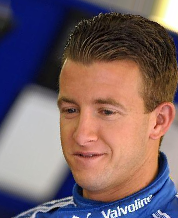

In [6]:
from PIL import Image
from IPython.display import display

train_labels = celeba_train["Smiling"]
TARGET_INDEX = next(
    i for i, label in enumerate(train_labels) if int(label) == TARGET_CLASS
)

target_item = celeba_train[TARGET_INDEX]
target_label = int(target_item["Smiling"])
assert target_label == TARGET_CLASS == 0

target_image = target_item["image"].convert("RGB")

TARGET_DIR = CODE_ROOT / "data" / "samples" / "celeba_target"
TARGET_DIR.mkdir(parents=True, exist_ok=True)
TARGET_PATH = TARGET_DIR / TARGET_FILENAME
TARGET_METADATA_PATH = ARTIFACTS_ROOT / "training_member_target_metadata.json"

target_image.save(TARGET_PATH, format="PNG")

target_metadata = {
    "dataset": "flwrlabs/celeba",
    "split": "train",
    "target_index": int(TARGET_INDEX),
    "target_class": int(target_label),
    "class_attribute": "Smiling",
    "is_victim_training_member": True,
    "selection_rule": "first training example with Smiling == 0",
    "filename": TARGET_PATH.name,
    "original_size": list(target_image.size),
    "original_mode": target_image.mode,
    "preprocessing": (
        "Resize((256,256)) -> ToTensor() -> "
        "Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))"
    ),
}
TARGET_METADATA_PATH.write_text(json.dumps(target_metadata, indent=2))

target_tensor = CELEBA_TRANSFORM(target_image).unsqueeze(0).to(DEVICE)

print("CelebA split       : train")
print("Training-set index :", TARGET_INDEX)
print("Smiling/class      :", target_label)
print("Training member    : yes")
print("Original size      :", target_image.size)
print("Attack shape       :", tuple(target_tensor.shape))
print("Saved target       :", TARGET_PATH)
print("Saved metadata     :", TARGET_METADATA_PATH)

display(target_image)


## 7. Train the authors' `MLP_1` victim for 3 epochs

The architecture is imported directly from the authors' release. Training uses the same optimizer/hyperparameters as the `01_ggssr_baseline_reconstruction.ipynb` notebook. The difference is that the victim model is trained locally for *3 epochs*, instead of only 1. This is intended to test the hypothesis of whether a longer-trained model is easier to reconstruct from. The speculation is that, since a model trained for more epochs sees the same data multiple times, it has higher chances of memorizing the samples and possibly overfitting on them, and thus higher chances of producing uniquely identifiable gradients for each sample image. If the hypothesis holds true, it can lead to better image reconstruction from a leaked gradient in this notebook than in the previous notebook.

A raw model `state_dict` is saved after every completed epoch as `MLP_1_epoch_01.pth`, `MLP_1_epoch_02.pth`, and `MLP_1_epoch_03.pth`. The authors' attack code expects `model_state/MLP_1.pth`, so after every completed epoch, that path is refreshed with the newest state.

If the notebook is restarted after a completed epoch, training resumes from the highest valid epoch checkpoint and runs only the remaining epochs. This is to protect completed epochs from network disconnects or power loss.

In [7]:
import torch.nn as nn

BATCH_SIZE = 64
NUM_WORKERS = 0
EPOCHS = 3
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
FORCE_RETRAIN = False

REPO_CHECKPOINT_DIR = CODE_ROOT / "model_state"
REPO_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
VICTIM_CHECKPOINT = REPO_CHECKPOINT_DIR / "MLP_1.pth"

class CelebASmilingDataset(Dataset):
    def __init__(self, hf_dataset, transform):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        item = self.dataset[index]
        image = self.transform(item["image"])
        label = torch.tensor(int(item["Smiling"]), dtype=torch.long)
        return image, label

train_dataset = CelebASmilingDataset(celeba_train, CELEBA_TRANSFORM)

from guided_diffusion.attacked_model import MLP_1


def epoch_checkpoint(epoch_number):
    return CHECKPOINTS_ROOT / f"MLP_1_epoch_{epoch_number:02d}.pth"


def completed_epochs():
    completed = []
    for epoch_number in range(1, EPOCHS + 1):
        path = epoch_checkpoint(epoch_number)
        if path.is_file() and path.stat().st_size > 1_000_000:
            completed.append(epoch_number)
    return completed

if FORCE_RETRAIN:
    for path in CHECKPOINTS_ROOT.glob("MLP_1_epoch_*.pth"):
        path.unlink()
    if VICTIM_CHECKPOINT.exists():
        VICTIM_CHECKPOINT.unlink()

victim_model = MLP_1().to(DEVICE)
num_params = sum(p.numel() for p in victim_model.parameters())

existing_epochs = completed_epochs()
start_epoch = max(existing_epochs, default=0)

if start_epoch:
    resume_path = epoch_checkpoint(start_epoch)
    victim_model.load_state_dict(torch.load(resume_path, map_location=DEVICE))
    shutil.copy2(resume_path, VICTIM_CHECKPOINT)
    print(f"Resuming from completed epoch {start_epoch}: {resume_path.name}")
else:
    print("No completed experiment checkpoint found; starting from a fresh MLP_1.")

print(f"Victim architecture : {type(victim_model).__name__}")
print(f"Parameters          : {num_params:,}")
print(f"Training samples    : {len(train_dataset):,}")
print(f"Target epochs       : {EPOCHS}")
print("Checkpoint folder  :", CHECKPOINTS_ROOT)
print("Attack checkpoint  :", VICTIM_CHECKPOINT)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    victim_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

training_history = []

for epoch_number in range(start_epoch + 1, EPOCHS + 1):
    # A deterministic per-epoch shuffle makes the data order reproducible even
    # when execution resumes at an epoch boundary.
    loader_generator = torch.Generator()
    loader_generator.manual_seed(SEED + epoch_number)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=True,
        generator=loader_generator,
    )

    victim_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    print(f"\nEpoch {epoch_number}/{EPOCHS}")

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = victim_model(images)
        loss = criterion(outputs, labels)

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite loss at epoch {epoch_number}, batch {batch_idx}: {loss.item()}"
            )

        loss.backward()
        optimizer.step()

        batch_n = labels.size(0)
        running_loss += loss.item() * batch_n
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += batch_n

        if (
            batch_idx == 0
            or (batch_idx + 1) % 250 == 0
            or (batch_idx + 1) == len(train_loader)
        ):
            print(
                f"  batch {batch_idx + 1:5d}/{len(train_loader):5d} | "
                f"loss {running_loss / total:.4f} | "
                f"accuracy {100.0 * correct / total:.2f}%"
            )

    epoch_loss = running_loss / total
    epoch_accuracy = 100.0 * correct / total
    epoch_path = epoch_checkpoint(epoch_number)

    torch.save(victim_model.state_dict(), epoch_path)
    shutil.copy2(epoch_path, VICTIM_CHECKPOINT)

    training_history.append({
        "epoch": epoch_number,
        "train_loss": epoch_loss,
        "train_accuracy_percent": epoch_accuracy,
        "checkpoint": str(epoch_path),
        "checkpoint_sha256": sha256_file(epoch_path),
    })

    print(f"Epoch {epoch_number} complete.")
    print(f"  loss       : {epoch_loss:.6f}")
    print(f"  accuracy   : {epoch_accuracy:.2f}%")
    print(f"  checkpoint : {epoch_path}")
    print(f"  latest     : {VICTIM_CHECKPOINT}")

# If all epochs were already present, refresh the canonical attack checkpoint.
final_epoch_path = epoch_checkpoint(EPOCHS)
if not final_epoch_path.is_file():
    raise RuntimeError(
        f"Expected final epoch checkpoint does not exist: {final_epoch_path}"
    )
shutil.copy2(final_epoch_path, VICTIM_CHECKPOINT)

print("\nVictim preparation complete.")
print("Completed epoch checkpoints:")
for epoch_number in completed_epochs():
    print(" -", epoch_checkpoint(epoch_number))
print("Canonical attack checkpoint:", VICTIM_CHECKPOINT)


No completed experiment checkpoint found; starting from a fresh MLP_1.
Victim architecture : MLP_1
Parameters          : 100,729,730
Training samples    : 162,770
Target epochs       : 3
Checkpoint folder  : /content/checkpoints/training_member_3epoch
Attack checkpoint  : /content/vendor/ggssr_code/model_state/MLP_1.pth

Epoch 1/3
  batch     1/ 2543 | loss 0.6828 | accuracy 64.06%
  batch   250/ 2543 | loss 0.4601 | accuracy 79.78%
  batch   500/ 2543 | loss 0.4036 | accuracy 82.55%
  batch   750/ 2543 | loss 0.3723 | accuracy 83.99%
  batch  1000/ 2543 | loss 0.3551 | accuracy 84.80%
  batch  1250/ 2543 | loss 0.3409 | accuracy 85.39%
  batch  1500/ 2543 | loss 0.3304 | accuracy 85.84%
  batch  1750/ 2543 | loss 0.3224 | accuracy 86.21%
  batch  2000/ 2543 | loss 0.3168 | accuracy 86.49%
  batch  2250/ 2543 | loss 0.3114 | accuracy 86.71%
  batch  2500/ 2543 | loss 0.3074 | accuracy 86.91%
  batch  2543/ 2543 | loss 0.3066 | accuracy 86.95%
Epoch 1 complete.
  loss       : 0.306610
 

## 8. Held-out victim-model sanity check

Although the reconstruction target is a training member, the victim is still evaluated on CelebA's held-out test split. This verifies whether the locally trained checkpoint is a functioning classifier, and records its generalization accuracy.


In [8]:
test_dataset = CelebASmilingDataset(celeba_test, CELEBA_TRANSFORM)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

victim_model = MLP_1().to(DEVICE)
victim_model.load_state_dict(torch.load(VICTIM_CHECKPOINT, map_location=DEVICE))
victim_model.eval()

correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        outputs = victim_model(images)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

test_accuracy = 100.0 * correct / total
print(f"Held-out CelebA test accuracy: {test_accuracy:.2f}%")

if test_accuracy <= 60.0:
    raise RuntimeError(
        "Victim model appears insufficiently trained. Do not proceed to reconstruction."
    )

# Confirm the chosen image is truly class 0 and is handled by the trained victim.
with torch.no_grad():
    target_logits = victim_model(target_tensor)
    target_prediction = int(target_logits.argmax(dim=1).item())

print("Target true class       :", target_label)
print("Victim target prediction:", target_prediction)
print("Victim-model sanity check passed.")


Held-out CelebA test accuracy: 89.97%
Target true class       : 0
Victim target prediction: 0
Victim-model sanity check passed.


## 9. Apply minimal compatibility / output patches

The authors' reconstruction logic is intentionally left intact. This cell applies only the changes required by this experiment:

- `ReconstructionOperator` still assumes class 0, but expresses that target as a `torch.long` class index rather than a one-hot floating tensor;
- the runner creates the `progresss/<sample>` directory before passing it as `save_root`; and
- `gaussian_diffusion.py` saves `x_t` and predicted `x_0` only every 100 timesteps plus `t=0`, under the experiment's own output directory. This ensures that the resuls directory is not flooded with a thousand reconstructed images, while still allowing progress trajectory to be tracked every hundred timesteps.


In [9]:
MEASUREMENTS_PATH = CODE_ROOT / "guided_diffusion" / "measurements.py"
RUNNER_PATH = CODE_ROOT / "sample_condition_same_inputs.py"
GD_PATH = CODE_ROOT / "guided_diffusion" / "gaussian_diffusion.py"

# ------------------------------------------------------------
# Patch 1: explicit integer class-0 target in ReconstructionOperator.
# ------------------------------------------------------------
measurements_original = "label_pic_00000 = torch.tensor([[1.,0.]]).to(self.device)"
measurements_patched = (
    "label_pic_00000 = torch.tensor([0], dtype=torch.long, device=self.device)"
)

measurements_text = MEASUREMENTS_PATH.read_text()
if measurements_patched in measurements_text:
    print("Class-0 label patch already present.")
elif measurements_original in measurements_text:
    MEASUREMENTS_PATH.write_text(
        measurements_text.replace(measurements_original, measurements_patched, 1)
    )
    print("Class-0 label patch applied.")
else:
    raise RuntimeError(
        "Expected ReconstructionOperator label line was not found. "
        "The source may contain unrelated/debug modifications; use a fresh authors' code copy."
    )

# ------------------------------------------------------------
# Patch 2: create the directory passed as save_root.
# ------------------------------------------------------------
runner_original = """        sample, distance_list = sample_fn(x_start=x_start, measurement=y_n, record=True,
                                          save_root=os.path.join(out_path, 'progresss', str(i).zfill(5)))"""

runner_patched = """        progress_dir = os.path.join(
            out_path,
            'progresss',
            str(i).zfill(5)
        )
        os.makedirs(progress_dir, exist_ok=True)

        sample, distance_list = sample_fn(
            x_start=x_start,
            measurement=y_n,
            record=True,
            save_root=progress_dir
        )"""

runner_text = RUNNER_PATH.read_text()
if runner_patched in runner_text:
    print("Runner progress-directory patch already present.")
elif runner_original in runner_text:
    RUNNER_PATH.write_text(runner_text.replace(runner_original, runner_patched, 1))
    print("Runner progress-directory patch applied.")
else:
    raise RuntimeError(
        "Expected runner save_root block was not found. "
        "The source may contain unrelated/debug modifications; use a fresh authors' code copy."
    )

# ------------------------------------------------------------
# Patch 3: sparse trajectory saving under save_root/x0.
# ------------------------------------------------------------
gd_original = """            if record:
                file_path = os.path.join(save_root, f"x_{str(idx).zfill(4)}.png")
                x0_file_path = os.path.join('code/results/reconstruction/progress/x0', f"x_{str(idx).zfill(4)}.png")
                plt.imsave(file_path, clear_color(img))
                plt.imsave(x0_file_path, clear_color(out['pred_xstart']) )"""

gd_patched = """            # Save sparse reconstruction trajectory snapshots.
            if record and (idx % 100 == 0 or idx == 0):
                file_path = os.path.join(
                    save_root,
                    f"x_{str(idx).zfill(4)}.png"
                )

                x0_file_path = os.path.join(
                    save_root,
                    "x0",
                    f"x_{str(idx).zfill(4)}.png"
                )

                os.makedirs(
                    os.path.dirname(x0_file_path),
                    exist_ok=True
                )

                plt.imsave(
                    file_path,
                    clear_color(img)
                )

                plt.imsave(
                    x0_file_path,
                    clear_color(out['pred_xstart'])
                )"""

gd_text = GD_PATH.read_text()
if gd_patched in gd_text:
    print("Sparse trajectory patch already present.")
elif gd_original in gd_text:
    GD_PATH.write_text(gd_text.replace(gd_original, gd_patched, 1))
    print("Sparse trajectory patch applied.")
else:
    raise RuntimeError(
        "Expected gaussian_diffusion.py save block was not found. "
        "The source may contain unrelated/debug modifications; use a fresh authors' code copy."
    )

# ------------------------------------------------------------
# Narrow verification: only the intended behaviors are asserted.
# ------------------------------------------------------------
measurements_verify = MEASUREMENTS_PATH.read_text()
runner_verify = RUNNER_PATH.read_text()
gd_verify = GD_PATH.read_text()

assert measurements_patched in measurements_verify
assert ("create_graph=True" in measurements_verify or "create_graph = True" in measurements_verify)
assert "allow_unused=True" not in measurements_verify
assert "os.makedirs(progress_dir, exist_ok=True)" in runner_verify
assert "save_root=progress_dir" in runner_verify
assert "if record and (idx % 100 == 0 or idx == 0):" in gd_verify
assert 'save_root,\n                    "x0",' in gd_verify

print("\nCompatibility-patch verification passed.")
print("Modified only:")
print(" -", MEASUREMENTS_PATH)
print(" -", RUNNER_PATH)
print(" -", GD_PATH)


Class-0 label patch applied.
Runner progress-directory patch applied.
Sparse trajectory patch applied.

Compatibility-patch verification passed.
Modified only:
 - /content/vendor/ggssr_code/guided_diffusion/measurements.py
 - /content/vendor/ggssr_code/sample_condition_same_inputs.py
 - /content/vendor/ggssr_code/guided_diffusion/gaussian_diffusion.py


## 10. Record the experiment configuration

The run configuration records the experimental variables, target membership / class, hashes of the victim and diffusion checkpoints, software environment, and the known differences from the authors' release. This file is updated again after evaluation with the resulting metrics/artifact paths.


In [10]:
import importlib.metadata as importlib_metadata

EXPERIMENT_ROOT = (RESULTS_ROOT / "training_member_3epoch_fixed_mr").resolve()
EXPERIMENT_ROOT.mkdir(parents=True, exist_ok=True)
RUN_CONFIG_PATH = EXPERIMENT_ROOT / "run_config.json"

def package_version(name):
    try:
        return importlib_metadata.version(name)
    except importlib_metadata.PackageNotFoundError:
        return None

def git_commit(path):
    try:
        result = subprocess.run(
            ["git", "-C", str(path), "rev-parse", "HEAD"],
            check=True,
            capture_output=True,
            text=True,
        )
        return result.stdout.strip()
    except Exception:
        return None

per_epoch_checkpoints = []
for epoch_number in completed_epochs():
    path = epoch_checkpoint(epoch_number)
    per_epoch_checkpoints.append({
        "epoch": epoch_number,
        "path": str(path),
        "sha256": sha256_file(path),
    })

run_config = {
    "seed": SEED,
    "dataset": "flwrlabs/celeba",
    "experiment": "training-member target with 3-epoch victim",
    "hypothesis": (
        "Greater victim fitting plus training-set membership may yield a more image-specific "
        "leaked-gradient signal and improve reconstruction; this is evaluated rather than assumed."
    ),
    "victim_architecture": "authors' MLP_1",
    "victim_training": {
        "split": "train",
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "test_accuracy_percent": test_accuracy,
        "epoch_checkpoints": per_epoch_checkpoints,
    },
    "target": {
        "split": "train",
        "index": int(TARGET_INDEX),
        "class_attribute": "Smiling",
        "class": int(target_label),
        "is_victim_training_member": True,
        "selection_rule": "first training example with Smiling == 0",
        "victim_prediction": int(target_prediction),
        "path": str(TARGET_PATH),
    },
    "attack": {
        "method": "GSS",
        "guidance_scale": 0.20,
        "interval": 1,
        "diffusion_steps": 1000,
        "diffusion_config": "configs/diffusion_ddim1000_config.yaml",
        "task_config": "configs/reconstruction_config.yaml",
        "gradient_noise_used_by_runner": "none (y_n = y in authors' runner)",
        "required_device": "CUDA GPU",
    },
    "source_changes": [
        "Represent the authors' hard-coded class-0 target as a LongTensor class index.",
        "Create the progress directory before passing it as save_root.",
        "Save sparse x_t and predicted-x_0 snapshots every 100 steps and at t=0.",
    ],
    "checkpoints": {
        "victim_latest_path": str(VICTIM_CHECKPOINT),
        "victim_latest_sha256": sha256_file(VICTIM_CHECKPOINT),
        "diffusion_path": str(DIFFUSION_CHECKPOINT),
        "diffusion_sha256": sha256_file(DIFFUSION_CHECKPOINT),
    },
    "environment": {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "torch": torch.__version__,
        "torchvision": torchvision.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda,
        "device": str(DEVICE),
        "gpu": torch.cuda.get_device_name(0),
        "datasets": package_version("datasets"),
        "lpips": package_version("lpips"),
        "opacus": package_version("opacus"),
    },
    "authors_repo_commit": git_commit(author_git_root) if author_git_root.exists() else None,
}

RUN_CONFIG_PATH.write_text(json.dumps(run_config, indent=2))
print(json.dumps(run_config, indent=2))
print("\nRun configuration saved to:", RUN_CONFIG_PATH)


{
  "seed": 2026,
  "dataset": "flwrlabs/celeba",
  "experiment": "training-member target with 3-epoch victim",
  "hypothesis": "Greater victim fitting plus training-set membership may yield a more image-specific leaked-gradient signal and improve reconstruction; this is evaluated rather than assumed.",
  "victim_architecture": "authors' MLP_1",
  "victim_training": {
    "split": "train",
    "epochs": 3,
    "batch_size": 64,
    "learning_rate": 0.0001,
    "weight_decay": 1e-05,
    "test_accuracy_percent": 89.96593527702635,
    "epoch_checkpoints": [
      {
        "epoch": 1,
        "path": "/content/checkpoints/training_member_3epoch/MLP_1_epoch_01.pth",
        "sha256": "89ee7d95f4efa97843d3cb7fbb575fa498899630864e17acf883e2161a2bd509"
      },
      {
        "epoch": 2,
        "path": "/content/checkpoints/training_member_3epoch/MLP_1_epoch_02.pth",
        "sha256": "e3f60af3ccd67e96cbc0322864b2130411dbe477ba9a3d7c5e06aa194d81caec"
      },
      {
        "epoch": 3,
 

## 11. Run GGSS-R reconstruction

This invokes the runner from the authors' code directory. The reconstruction results produced are organized in accordance to the authors' deisgn as well. The attack configuration is unchanged from the fixed-guidance baseline: GSS, guidance rate `0.2`, 1000 DDIM steps, interval `1`, and no added gradient noise in the released runner (`y_n = y`).

The scientific differences in this notebook are upstream of the attack: the victim has been trained for 3 epochs and the target is a class-0 victim-training member.


In [11]:
# Start this experiment with a clean result directory while retaining victim checkpoints.
if EXPERIMENT_ROOT.exists():
    for child in EXPERIMENT_ROOT.iterdir():
        if child.name != RUN_CONFIG_PATH.name:
            if child.is_dir():
                shutil.rmtree(child)
            else:
                child.unlink()

required_files = [
    RUNNER_PATH,
    MEASUREMENTS_PATH,
    GD_PATH,
    CODE_ROOT / "configs" / "model_config.yaml",
    CODE_ROOT / "configs" / "diffusion_ddim1000_config.yaml",
    CODE_ROOT / "configs" / "reconstruction_config.yaml",
    DIFFUSION_CHECKPOINT,
    VICTIM_CHECKPOINT,
    TARGET_PATH,
]
for path in required_files:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for the GGSS-R run in this notebook.")

cmd = [
    sys.executable,
    "sample_condition_same_inputs.py",
    "--model_config", "configs/model_config.yaml",
    "--diffusion_config", "configs/diffusion_ddim1000_config.yaml",
    "--task_config", "configs/reconstruction_config.yaml",
    "--gpu", "0",
    "--interval", "1",
    "--save_dir", str(EXPERIMENT_ROOT),
    "--method", "GSS",
    "--data_root", "data/samples/celeba_target/",
    "--guidance_scale", "0.2",
]

print("Experiment       : training-member / 3-epoch victim")
print("Attack method    : GSS")
print("Guidance rate    : 0.20")
print("Diffusion steps  : 1000")
print("Gradient noise   : none")
print("Victim           : authors' MLP_1")
print("Victim epochs    :", EPOCHS)
print("Target split     : CelebA train")
print("Target index     :", TARGET_INDEX)
print("Target class     :", target_label)
print("Training member  : yes")
print("Device           :", torch.cuda.get_device_name(0))
print("Output           :", EXPERIMENT_ROOT)
print("\nCommand:")
print(" ".join(cmd))
print("\nStarting GGSS-R...\n")

process = subprocess.Popen(
    cmd,
    cwd=str(CODE_ROOT),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

def is_noisy_debug_line(line):
    stripped = line.strip()
    # Suppress the authors' repeated per-step tensor-shape/sigma debug prints,
    # while leaving substantive progress/errors visible.
    return "torch.Size(" in stripped or stripped.startswith("tensor(")

try:
    for line in iter(process.stdout.readline, ""):
        if is_noisy_debug_line(line):
            continue
        print(line, end="", flush=True)
finally:
    if process.stdout is not None:
        process.stdout.close()

return_code = process.wait()
if return_code != 0:
    raise RuntimeError(f"GGSS-R exited with return code {return_code}.")

print("\nGGSS-R reconstruction completed.")
print("Results:", EXPERIMENT_ROOT)


Experiment       : training-member / 3-epoch victim
Attack method    : GSS
Guidance rate    : 0.20
Diffusion steps  : 1000
Gradient noise   : none
Victim           : authors' MLP_1
Victim epochs    : 3
Target split     : CelebA train
Target index     : 4
Target class     : 0
Training member  : yes
Device           : Tesla T4
Output           : /content/results/training_member_3epoch_fixed_mr

Command:
/usr/bin/python3 sample_condition_same_inputs.py --model_config configs/model_config.yaml --diffusion_config configs/diffusion_ddim1000_config.yaml --task_config configs/reconstruction_config.yaml --gpu 0 --interval 1 --save_dir /content/results/training_member_3epoch_fixed_mr --method GSS --data_root data/samples/celeba_target/ --guidance_scale 0.2

Starting GGSS-R...

2026-09-02 15:44:39,546 [DPS] >> Device set to cuda:0.
09/02/2026 15:44:39:INFO:Device set to cuda:0.
2026-09-02 15:44:42,155 [DPS] >> Operation: reconstruction / Noise: gaussian
09/02/2026 15:44:42:INFO:Operation: reconst

## 12. Reconstruction trajectory

The sparse-saving patch records raw `x_t` and predicted `x_0` snapshots every 100 steps, including the final `t=0` state. While `x_0` images contain the denoised raw state, it is the `x_t` images which contain the denoised reconstruction predictions at timesteps and are thus more useful for interpreting reconstruction progress. The figure below shows the latter predicted images. The grid is both displayed inline and saved as `reconstruction_grid.png`.


Saved x_t snapshots : 10
Saved x0 snapshots  : 10
Timesteps           : [900, 800, 700, 600, 500, 400, 300, 200, 100, 0]


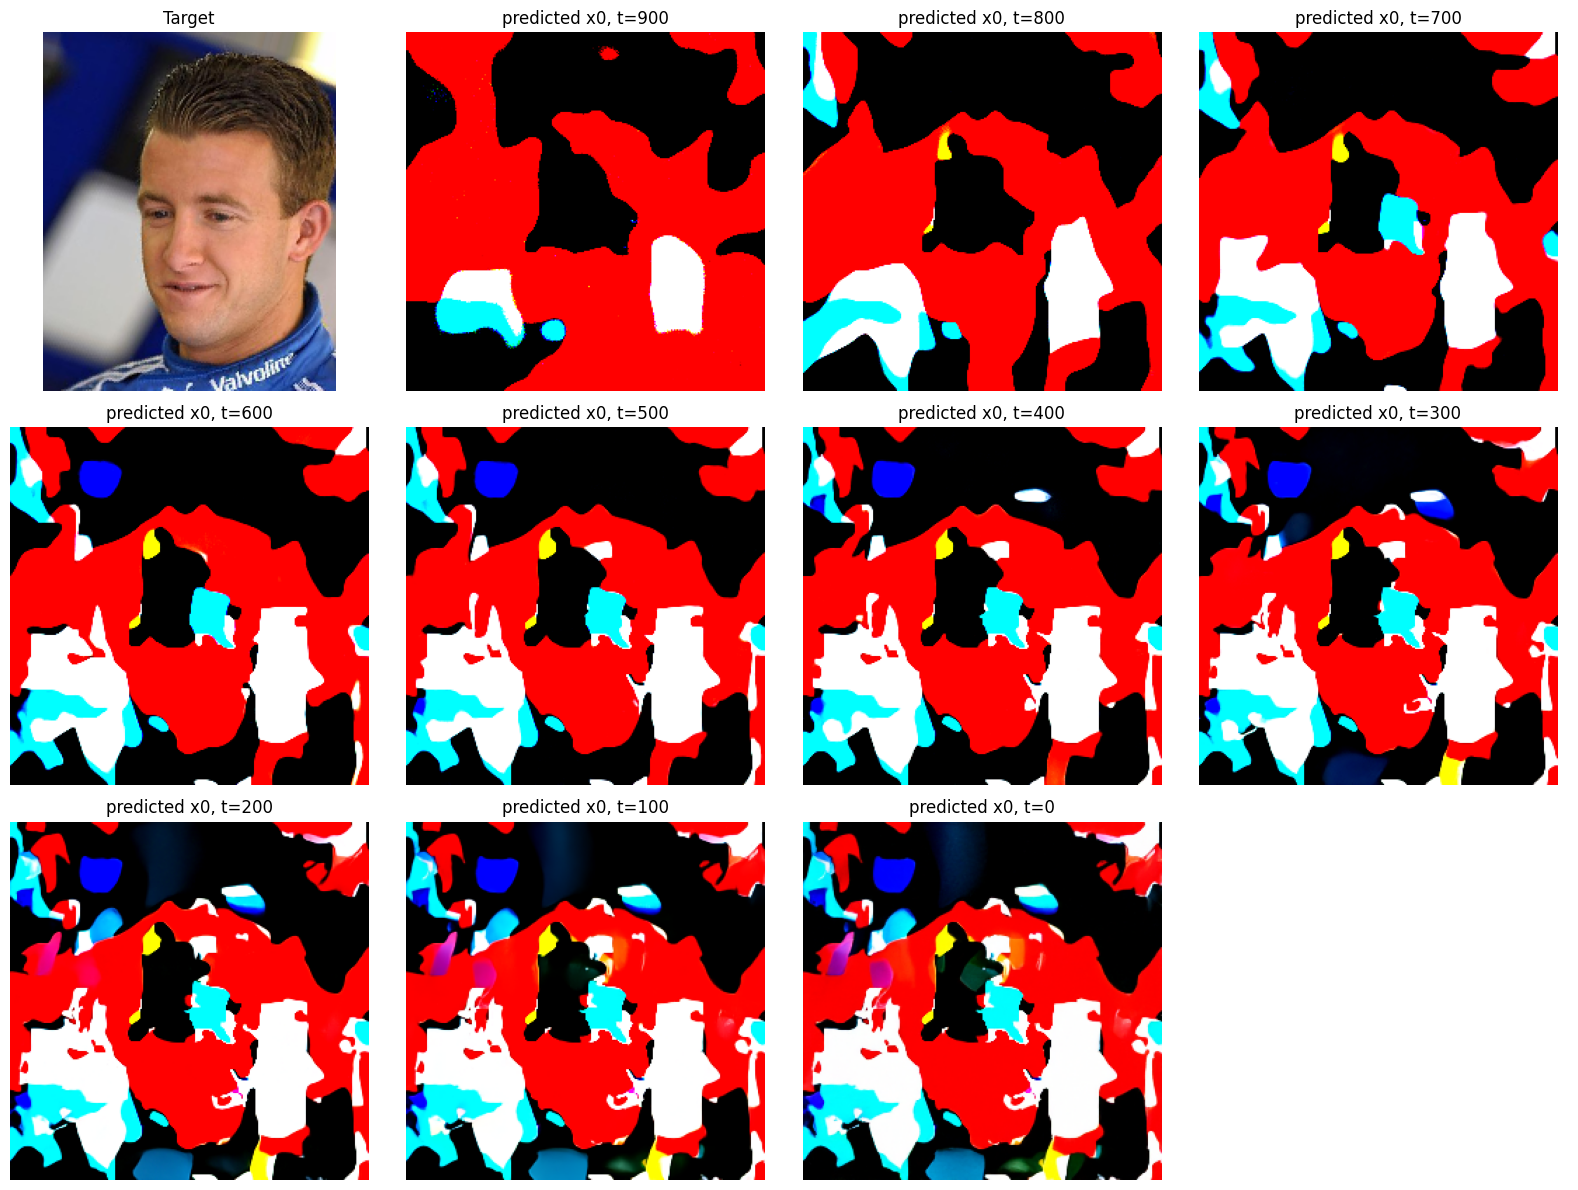

Saved reconstruction grid: /content/results/training_member_3epoch_fixed_mr/reconstruction_grid.png


In [12]:
import matplotlib.pyplot as plt

PROGRESS_ROOT = (
    EXPERIMENT_ROOT / "reconstruction" / "progresss" / "00000"
)
X_ROOT = PROGRESS_ROOT
X0_ROOT = PROGRESS_ROOT / "x0"

if not X_ROOT.is_dir():
    raise FileNotFoundError(
        f"Reconstruction progress directory not found: {X_ROOT}"
    )

def discover_snapshots(root):
    snapshots = {}
    for path in sorted(root.glob("x_*.png")):
        try:
            timestep = int(path.stem.split("_")[1])
        except (IndexError, ValueError):
            continue
        snapshots[timestep] = path
    return snapshots

x_snapshots = discover_snapshots(X_ROOT)
x0_snapshots = discover_snapshots(X0_ROOT)
common_timesteps = sorted(set(x_snapshots) & set(x0_snapshots), reverse=True)

print("Saved x_t snapshots :", len(x_snapshots))
print("Saved x0 snapshots  :", len(x0_snapshots))
print("Timesteps           :", common_timesteps)

if not common_timesteps:
    raise RuntimeError("No common x_t / predicted-x_0 snapshots were found.")

images = [("Target", target_image)]
for timestep in common_timesteps:
    img = Image.open(x0_snapshots[timestep]).convert("RGB")
    images.append((f"predicted x0, t={timestep}", img))

ncols = 4
nrows = int(np.ceil(len(images) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (title, img) in zip(axes, images):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
for ax in axes[len(images):]:
    ax.axis("off")

fig.tight_layout()
GRID_PATH = EXPERIMENT_ROOT / "reconstruction_grid.png"
fig.savefig(GRID_PATH, dpi=160, bbox_inches="tight")
plt.show()
print("Saved reconstruction grid:", GRID_PATH)


## 13. Quantitative evaluation: MSE, PSNR, and LPIPS

The target is resized to `256 × 256`, matching the attack runner. MSE and PSNR are calculated on `[0,1]` image tensors. LPIPS uses the corresponding `[-1,1]` representation. Metrics are computed for both the raw `x_t` snapshots and predicted `x_0` snapshots and saved to `evaluation/metrics.csv`.


In [13]:
import math
import pandas as pd
import torch.nn.functional as F
import lpips

EVAL_ROOT = EXPERIMENT_ROOT / "evaluation"
EVAL_ROOT.mkdir(parents=True, exist_ok=True)
METRICS_CSV = EVAL_ROOT / "metrics.csv"

target_resized = transforms.Resize((256, 256))(target_image)
target_01 = transforms.ToTensor()(target_resized).unsqueeze(0).to(DEVICE)

lpips_model = lpips.LPIPS(net="alex").to(DEVICE)
lpips_model.eval()

def load_snapshot(path):
    image = Image.open(path).convert("RGB")
    image = image.resize((256, 256), Image.Resampling.BILINEAR)
    return transforms.ToTensor()(image).unsqueeze(0).to(DEVICE)

def compute_metrics(image_01, target_01):
    mse = F.mse_loss(image_01, target_01).item()
    psnr = float("inf") if mse == 0 else 10.0 * math.log10(1.0 / mse)

    image_lpips = image_01 * 2.0 - 1.0
    target_lpips = target_01 * 2.0 - 1.0
    with torch.no_grad():
        lpips_value = lpips_model(image_lpips, target_lpips).mean().item()
    return mse, psnr, lpips_value

rows = []
for timestep in common_timesteps:
    x_img = load_snapshot(x_snapshots[timestep])
    x0_img = load_snapshot(x0_snapshots[timestep])

    x_mse, x_psnr, x_lpips = compute_metrics(x_img, target_01)
    x0_mse, x0_psnr, x0_lpips = compute_metrics(x0_img, target_01)

    rows.append({
        "timestep": timestep,
        "x_mse": x_mse,
        "x_psnr": x_psnr,
        "x_lpips": x_lpips,
        "x0_mse": x0_mse,
        "x0_psnr": x0_psnr,
        "x0_lpips": x0_lpips,
    })

df = pd.DataFrame(rows).sort_values("timestep").reset_index(drop=True)
df.to_csv(METRICS_CSV, index=False)
display(df)

best_x0_mse = df.loc[df["x0_mse"].idxmin()]
best_x0_psnr = df.loc[df["x0_psnr"].idxmax()]
best_x0_lpips = df.loc[df["x0_lpips"].idxmin()]

print("\nBest predicted x0 reconstruction:")
print(f"MSE   : t={int(best_x0_mse.timestep)}, {best_x0_mse.x0_mse:.6e}")
print(f"PSNR  : t={int(best_x0_psnr.timestep)}, {best_x0_psnr.x0_psnr:.4f} dB")
print(f"LPIPS : t={int(best_x0_lpips.timestep)}, {best_x0_lpips.x0_lpips:.6e}")
print("\nMetrics CSV:", METRICS_CSV)


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 148MB/s]


Loading model from: /usr/local/lib/python3.13/dist-packages/lpips/weights/v0.1/alex.pth


,timestep,x_mse,x_psnr,x_lpips,x0_mse,x0_psnr,x0_lpips
0,0,0.172187,7.639991,0.718507,0.172187,7.639991,0.718507
1,100,0.066266,11.787066,0.810816,0.177029,7.519544,0.722154
2,200,0.067640,11.697960,0.899350,0.180906,7.425479,0.726955
3,300,0.068580,11.638018,0.979319,0.183500,7.363651,0.736829
4,400,0.072883,11.373718,1.065161,0.186224,7.299644,0.739643
5,500,0.079372,11.003314,1.113968,0.187072,7.279920,0.743555
6,600,0.080756,10.928274,1.140840,0.189745,7.218289,0.738564
7,700,0.117948,9.283099,1.130329,0.192669,7.151892,0.753259
8,800,0.083717,10.771854,1.167691,0.203271,6.919252,0.772824
9,900,0.132029,8.793316,1.162607,0.218245,6.610555,0.783071



Best predicted x0 reconstruction:
MSE   : t=0, 1.721872e-01
PSNR  : t=0, 7.6400 dB
LPIPS : t=0, 7.185068e-01

Metrics CSV: /content/results/training_member_3epoch_fixed_mr/evaluation/metrics.csv


## 14. Metric trajectories

Each metric is visualized across the saved diffusion timesteps and written to disk as a PNG. These plots make it possible to inspect the reconstruction trajectory spanning across a thousand timesteps.


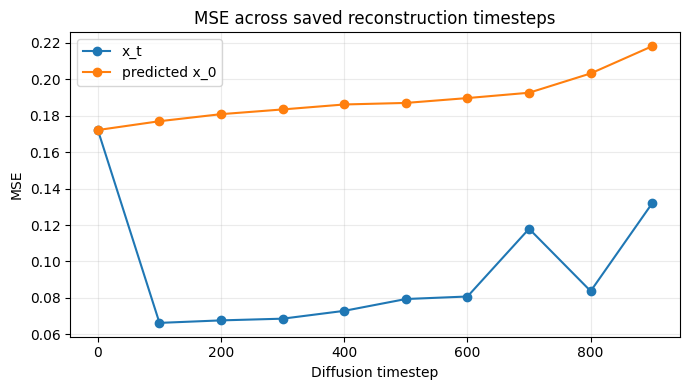

Saved: /content/results/training_member_3epoch_fixed_mr/evaluation/mse_trajectory.png


In [14]:
# MSE trajectory
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df["timestep"], df["x_mse"], marker="o", label="x_t")
ax.plot(df["timestep"], df["x0_mse"], marker="o", label="predicted x_0")
ax.set_xlabel("Diffusion timestep")
ax.set_ylabel("MSE")
ax.set_title("MSE across saved reconstruction timesteps")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

MSE_PLOT = EVAL_ROOT / "mse_trajectory.png"
fig.savefig(MSE_PLOT, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", MSE_PLOT)


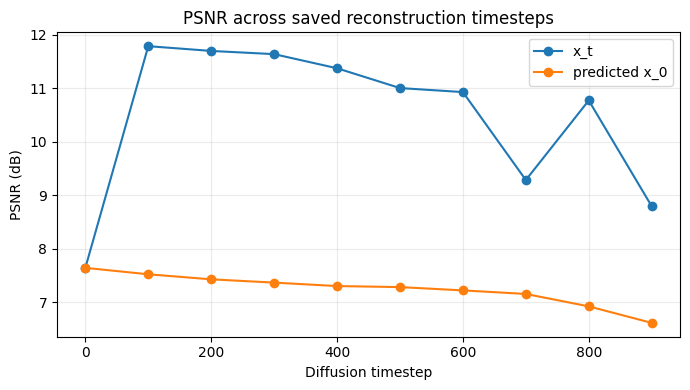

Saved: /content/results/training_member_3epoch_fixed_mr/evaluation/psnr_trajectory.png


In [15]:
# PSNR trajectory
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df["timestep"], df["x_psnr"], marker="o", label="x_t")
ax.plot(df["timestep"], df["x0_psnr"], marker="o", label="predicted x_0")
ax.set_xlabel("Diffusion timestep")
ax.set_ylabel("PSNR (dB)")
ax.set_title("PSNR across saved reconstruction timesteps")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

PSNR_PLOT = EVAL_ROOT / "psnr_trajectory.png"
fig.savefig(PSNR_PLOT, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", PSNR_PLOT)


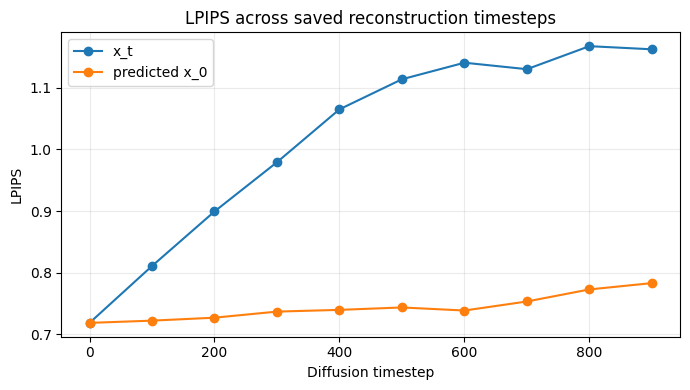

Saved: /content/results/training_member_3epoch_fixed_mr/evaluation/lpips_trajectory.png


In [16]:
# LPIPS trajectory
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df["timestep"], df["x_lpips"], marker="o", label="x_t")
ax.plot(df["timestep"], df["x0_lpips"], marker="o", label="predicted x_0")
ax.set_xlabel("Diffusion timestep")
ax.set_ylabel("LPIPS")
ax.set_title("LPIPS across saved reconstruction timesteps")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

LPIPS_PLOT = EVAL_ROOT / "lpips_trajectory.png"
fig.savefig(LPIPS_PLOT, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", LPIPS_PLOT)


## 15. Export the compact result bundle

The final target and reconstruction are copied to the experiment root alongside the reconstruction grid. `run_config.json` is updated with the best predicted-`x_0` metrics and all important artifact paths.

The resulting bundle of this notebook contains the same practical outputs as the previous notebook: target/final reconstruction PNGs, reconstruction grid, MSE/PSNR/LPIPS trajectory PNGs, `metrics.csv`, and `run_config.json`.


In [17]:
FINAL_RECON_SOURCE = (
    EXPERIMENT_ROOT / "reconstruction" / "recon" / "00000.png"
)
if not FINAL_RECON_SOURCE.is_file():
    raise FileNotFoundError(
        f"Final reconstruction was not found: {FINAL_RECON_SOURCE}"
    )

TARGET_EXPORT = EXPERIMENT_ROOT / "target.png"
FINAL_RECON_EXPORT = EXPERIMENT_ROOT / "final_reconstruction.png"
shutil.copy2(TARGET_PATH, TARGET_EXPORT)
shutil.copy2(FINAL_RECON_SOURCE, FINAL_RECON_EXPORT)

run_config["results"] = {
    "metrics_csv": str(METRICS_CSV),
    "reconstruction_grid": str(GRID_PATH),
    "mse_plot": str(MSE_PLOT),
    "psnr_plot": str(PSNR_PLOT),
    "lpips_plot": str(LPIPS_PLOT),
    "target": str(TARGET_EXPORT),
    "final_reconstruction": str(FINAL_RECON_EXPORT),
    "best_x0_mse": {
        "timestep": int(best_x0_mse.timestep),
        "value": float(best_x0_mse.x0_mse),
    },
    "best_x0_psnr": {
        "timestep": int(best_x0_psnr.timestep),
        "value": float(best_x0_psnr.x0_psnr),
    },
    "best_x0_lpips": {
        "timestep": int(best_x0_lpips.timestep),
        "value": float(best_x0_lpips.x0_lpips),
    },
}
RUN_CONFIG_PATH.write_text(json.dumps(run_config, indent=2))

print("Experiment artifacts:")
for path in [
    TARGET_EXPORT,
    FINAL_RECON_EXPORT,
    GRID_PATH,
    METRICS_CSV,
    MSE_PLOT,
    PSNR_PLOT,
    LPIPS_PLOT,
    RUN_CONFIG_PATH,
]:
    print(" -", path)


Experiment artifacts:
 - /content/results/training_member_3epoch_fixed_mr/target.png
 - /content/results/training_member_3epoch_fixed_mr/final_reconstruction.png
 - /content/results/training_member_3epoch_fixed_mr/reconstruction_grid.png
 - /content/results/training_member_3epoch_fixed_mr/evaluation/metrics.csv
 - /content/results/training_member_3epoch_fixed_mr/evaluation/mse_trajectory.png
 - /content/results/training_member_3epoch_fixed_mr/evaluation/psnr_trajectory.png
 - /content/results/training_member_3epoch_fixed_mr/evaluation/lpips_trajectory.png
 - /content/results/training_member_3epoch_fixed_mr/run_config.json


## 16. Result summary

As observed from the results of this notebook and the previous, the gradient inversion efforts on the longer-trained MLP are yielding worse reconstruction results.

From the grid of reconstructed images at progressive timesteps, it is clear that the diffusion model was not able to reconstruct any meaningful features of an image from the leaked gradient, and instead produced patches of color not representing the target image in any way.

From the MSE, PSNR and LPIPS as well, it is obvious that despite the gradient distance between the target image and the reconstructed image consistently going down throughout the reconstruction process, the metrics of image similarity evaluation suffer from significant fluctuations. MSE, which is supposed to progressively decrease in a successful reconstruction attack, appears to instead increase from ~0.17 to ~0.22, meaning that the target and predicted images are drifting away from each other in the pixel space. Likewise, the LPIPS metric is supposed to decrease, and is reported as 1.60e^-7 for CelebA under the MLP-3 architecture in Table 1 of the paper. However, from our experimental trajectory, we observe that LPIPS changes in the opposite direction; that is, the semantic feature alignment between the target and predicted images is deteriorating. This results in a final LPIPS of ~0.78, which is around 10^-7 times larger than what we are expected to get using the given victim model architecture and dataset.

Why the diffusion model is failing to reconstruct from the leaked gradient of the victim model remains to be diagnosed.

### Reproducibility notes

As observed from executing these cells in Google Colab using a T4 GPU:
- `MLP_1` has roughly 100 million parameters, so it takes long to train it (around 15-20 mins for each epoch) and its checkpoints are large in size.
- The full experiment requires a CUDA-capable GPU. The 1000-step reconstruction uses 20-30 seconds on a CPU and 1-2 seconds on a GPU for every step.

The target is selected from CelebA by index/attribute. No pre-existing local image is required.
